In [1]:
import os
print(os.listdir("../input"))

['amazon-alexa-reviews']


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [33]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [36]:
df = pd.read_csv("../input/amazon-alexa-reviews/amazon_alexa.tsv", sep="\t")

In [37]:
print("Dataset shape:", df.shape)

Dataset shape: (3150, 5)


In [39]:

print("\nFirst few rows:")
print(df.head())



First few rows:
   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  


In [40]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB
None


In [41]:
print("\nClass distribution:")
print(df['feedback'].value_counts())


Class distribution:
feedback
1    2893
0     257
Name: count, dtype: int64


In [50]:


# Initialize stopwords & lemmatizer once (not inside function for performance)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Clean and preprocess review text for NLP tasks.
    Steps:
    - handle missing values
    - lowercase conversion
    - remove special chars & digits
    - tokenization
    - stopword removal
    - lemmatization
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower()  # Convert to string & lowercase
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove digits & special characters, keep letters/spaces only
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)


In [51]:
print("Preprocessing review text...")

# Drop rows with missing or null reviews
df = df.dropna(subset=['verified_reviews'])

# Apply preprocessing to column
df['cleaned_text'] = df['verified_reviews'].apply(preprocess_text)

# Remove empty cleaned rows
df = df[df['cleaned_text'].str.strip() != ""]

df.reset_index(drop=True, inplace=True)

df[['verified_reviews','cleaned_text']].head()


Preprocessing review text...


,verified_reviews,cleaned_text
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...
4,Music,music


In [55]:
# Prepare features and labels
X = df['cleaned_text']
y = df['feedback']  # 1 for positive, 0 for negative

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Training set size: 2449
Testing set size: 613


In [58]:
# Feature extraction using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)
print("TF-IDF Shape:", X_test_tfidf.shape)

TF-IDF Shape: (2449, 5000)
TF-IDF Shape: (613, 5000)


In [59]:
# Model 1: Naive Bayes
print("\n" + "="*50)
print("Training Naive Bayes Classifier...")
print("="*50)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print("\nNaive Bayes Results:")
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))


Training Naive Bayes Classifier...

Naive Bayes Results:
Accuracy: 0.9233

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.92      1.00      0.96       566

    accuracy                           0.92       613
   macro avg       0.46      0.50      0.48       613
weighted avg       0.85      0.92      0.89       613



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [60]:
# Model 2: Logistic Regression
print("\n" + "="*50)
print("Training Logistic Regression...")
print("="*50)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))



Training Logistic Regression...

Logistic Regression Results:
Accuracy: 0.9233

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.92      1.00      0.96       566

    accuracy                           0.92       613
   macro avg       0.46      0.50      0.48       613
weighted avg       0.85      0.92      0.89       613



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


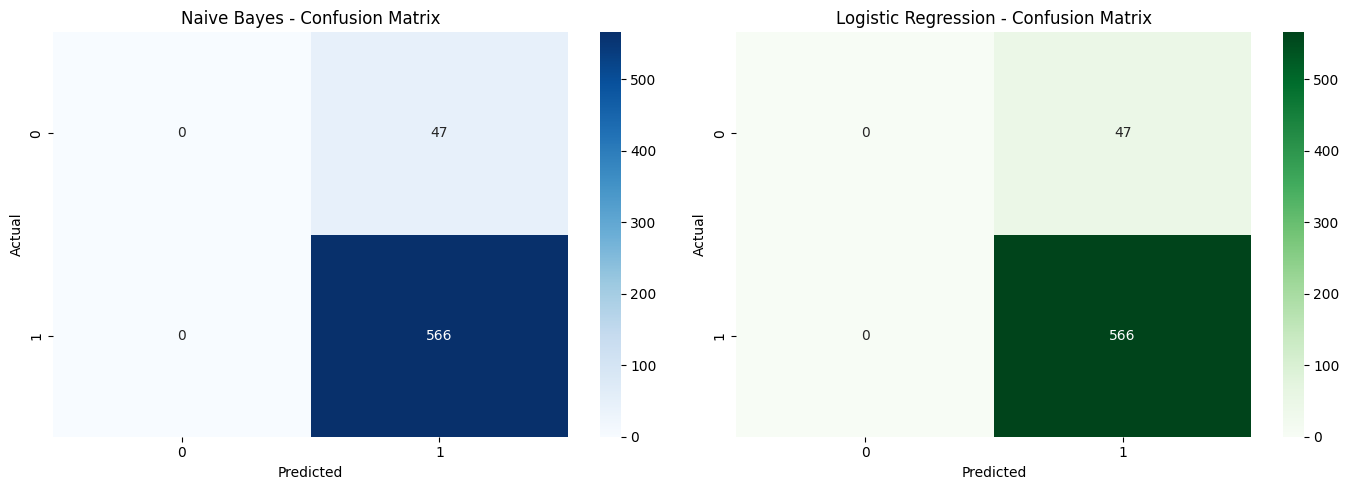

In [62]:
# Visualization 1: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

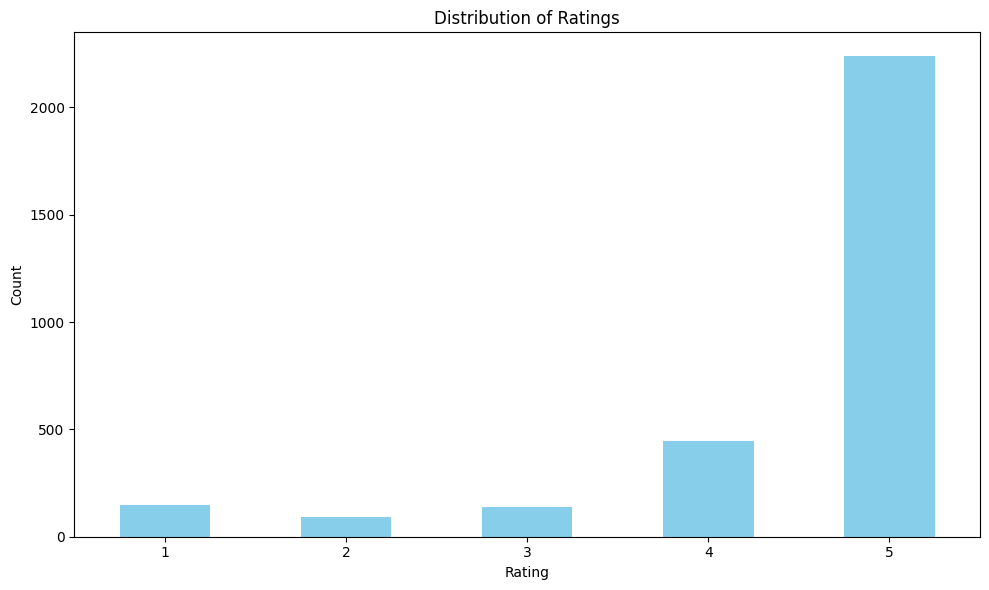

In [63]:
# Visualization 2: Rating distribution
plt.figure(figsize=(10, 6))
df['rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rating_distribution.png')
plt.show()

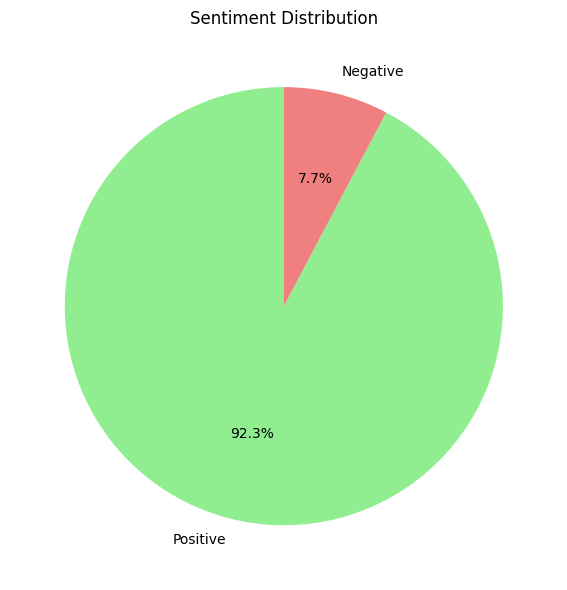

In [64]:
# Visualization 3: Sentiment distribution
plt.figure(figsize=(8, 6))
sentiment_counts = df['feedback'].value_counts()
plt.pie(sentiment_counts, labels=['Positive', 'Negative'], autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

In [65]:
# Function to predict sentiment for new reviews
def predict_sentiment(review, model=lr_model, vectorizer=tfidf):
    """Predict sentiment for a new review"""
    cleaned = preprocess_text(review)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = max(probability) * 100
    
    return sentiment, confidence

In [66]:
# Test with sample reviews
print("\n" + "="*50)
print("Testing with sample reviews:")
print("="*50)

sample_reviews = [
    "This Alexa is amazing! It works perfectly and understands everything I say.",
    "Terrible product. It doesn't work half the time and the sound quality is poor.",
    "It's okay, not great but does the job."
]

for review in sample_reviews:
    sentiment, confidence = predict_sentiment(review)
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)


Testing with sample reviews:

Review: This Alexa is amazing! It works perfectly and understands everything I say.
Predicted Sentiment: Positive (Confidence: 95.79%)

Review: Terrible product. It doesn't work half the time and the sound quality is poor.
Predicted Sentiment: Positive (Confidence: 50.71%)

Review: It's okay, not great but does the job.
Predicted Sentiment: Positive (Confidence: 95.67%)

Analysis Complete!
